In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


# 다이캐스팅 품질 데이터 전처리

## 1. 데이터 로드 및 기본 확인

In [89]:
# 데이터셋 로드
print("="*60)
df_full = pd.read_csv('../../data/DieCasting_Quality_Raw_Data.csv', header=[0, 1])
print("데이터셋 로드 완료!")

# 컬럼 이름에 공백 있는 컬럼 공백 제거
df_full.columns = pd.MultiIndex.from_tuples(
    [(group.strip(), col.strip()) for group, col in df_full.columns]
)
print("컬럼 이름 공백 제거 완료!")
print("="*60)

데이터셋 로드 완료!
컬럼 이름 공백 제거 완료!


In [90]:
# 데이터셋 정보 확인
print(f"Shape: {df_full.shape}")
print("\n[Data Info]")
df_full.info()

Shape: (7535, 57)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness)    7535 non-null   int64  
 10  (Process, Clamping_Force)       7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float64
 12  (Process, Pres

In [91]:
# 원본 데이터 기초 통계 확인
print("\n" + "="*60)
print("다이캐스팅 데이터셋 기초 통계")
print("="*60)
display(df_full.describe(include='all').T)


다이캐스팅 데이터셋 기초 통계


count          mean           std      min  \
Process id                    7535.0  3.767454e+06  2.175264e+06    1.000   
        Product_Type          7535.0  1.441672e+00  4.966192e-01    1.000   
        Shot                  7535.0  4.537989e+02  3.194517e+02    0.000   
        Velocity_1            7535.0  1.482190e-01  7.134201e-03    0.134   
        Velocity_2            7535.0  1.688005e-01  4.720277e-03    0.158   
        Velocity_3            7535.0  1.911928e-01  1.156281e-02    0.172   
        High_Velocity         7535.0  2.319210e+00  2.220408e-01    0.000   
        Cylinder_Pressure     7535.0  2.396556e+02  2.330545e+01  107.000   
        Rapid_Rise_Time       7535.0  9.596284e-03  2.147899e-03    0.000   
        Biscuit_Thickness     7535.0  1.430962e+01  3.286284e+00    0.000   
        Clamping_Force        7535.0  3.064333e+02  5.727496e+01  238.000   
        Cycle_Time            7535.0  2.773598e+01  8.716156e+00   20.200   
        Pressure_Rise_Time    7535.0  3.934811e-02  3.945136e-03    0.000   
        Casting_Pressure      7535.0  8.569441e+02  2.348155e+02  516.000   
        Spray_Time            7535.0  9.815979e+00  1.842438e+00    7.000   
        Spray_1_Time          7535.0  1.409104e+00  5.570595e-01    0.700   
        Spray_2_Time          7535.0  1.396045e+00  7.161698e-01    0.700   
Sensor  Melting_Furnace_Temp  7535.0  6.806527e+02  2.528867e+01  635.300   
        Air_Pressure          7535.0  6.109595e+00  6.479057e-01    4.600   
        Air_Pressure_Min      7535.0  3.000000e+00  0.000000e+00    3.000   
        Air_Pressure_Max      7535.0  9.000000e+00  0.000000e+00    9.000   
        Coolant_Temp          7535.0  2.683013e+01  5.251495e-01   25.900   
        Coolant_Temp_Min      7535.0  1.000000e+01  0.000000e+00   10.000   
        Coolant_Temp_Max      7535.0  5.000000e+01  0.000000e+00   50.000   
        Coolant_Pressure      7535.0  2.701155e+00  5.240785e-02    2.580   
        Factory_Temp          7445.0  3.282968e+01  1.674896e+00   27.400   
        Factory_Temp_Min      7445.0  1.800000e+01  0.000000e+00   18.000   
        Factory_Temp_Max      7445.0  2.200000e+01  0.000000e+00   22.000   
        Factory_Humidity      7445.0  6.167300e+01  7.031202e+00   45.500   
        Factory_Humidity_Min  7445.0  1.800000e+01  0.000000e+00   18.000   
        Factory_Humidity_Max  7445.0  2.200000e+01  0.000000e+00   22.000   
Defects Short_Shot_1          7535.0  6.794957e-02  2.594663e-01    0.000   
        Bubble_1              7535.0  9.555408e-03  9.729007e-02    0.000   
        Exfoliation_1         7535.0  2.322495e-02  1.523794e-01    0.000   
        Blow_Hole_1           7535.0  3.251493e-02  1.958671e-01    0.000   
        Stain_1               7535.0  2.773723e-02  1.796684e-01    0.000   
        Dent_1                7535.0  9.289980e-04  3.046733e-02    0.000   
        Deformation_1         7535.0  1.446583e-02  1.205152e-01    0.000   
        Contamination_1       7535.0  5.308560e-04  2.303572e-02    0.000   
        Impurity_1            7535.0  2.654280e-04  1.629088e-02    0.000   
        Crack_1               7535.0  1.327140e-04  1.152016e-02    0.000   
        Scratch_1             7535.0  2.654280e-04  1.629088e-02    0.000   
        Buring_Mark_1         7535.0  6.635700e-04  2.575301e-02    0.000   
        Inclusions_1          7535.0  0.000000e+00  0.000000e+00    0.000   
        Short_Shot_2          7535.0  2.415395e-02  1.552565e-01    0.000   
        Bubble_2              7535.0  1.194426e-03  4.152209e-02    0.000   
        Exfoliation_2         7535.0  1.778368e-02  1.351522e-01    0.000   
        Blow_Hole_2           7535.0  2.136695e-02  1.500199e-01    0.000   
        Stain_2               7535.0  0.000000e+00  0.000000e+00    0.000   
        Dent_2                7535.0  5.308560e-04  2.303572e-02    0.000   
        Deformation_2         7535.0  8.626410e-03  9.390737e-02    0.000   
        Contamination_2    

In [92]:
# 데이터셋 샘플 확인
print("\n" + "="*60)
print("DieCasting 샘플 데이터")
print("="*60)
display(df_full.head())


DieCasting 샘플 데이터


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                      \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness Clamping_Force   
0               214           0.008                10            258   
1               217           0.008                11            257   
2               214           0.008                11            257   
3               217           0.008                11            257   
4               217           0.008                12            257   

                                                                          \
  Cycle_Time Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7              0.044             1037        7.8          0.7   
1       20.7              0.044             1052        7.8          0.7   
2       20.8              0.041             1037        7.8          0.7   
3       20.7              0.043             1051        7.8          0.7   
4       20.7              0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0             0   
4        0 

## 2. 데이터 전처리

### 2-1. 중복 데이터 확인

In [93]:
print(f"전체 중복 데이터 개수: {df_full.duplicated().sum()}")
id_dup = df_full.duplicated(subset=[('Process', 'id')]).sum()
print(f"(process, id) 기준 중복 데이터 개수: {id_dup}")

전체 중복 데이터 개수: 0
(process, id) 기준 중복 데이터 개수: 0


### 2-2. 결측치 확인 및 처리

In [94]:
print("\n" + "="*60)
print("결측치 확인")
print("="*60)

missing_df = pd.DataFrame({
    '결측수': df_full.isnull().sum(),
    '결측비율(%)': (df_full.isnull().sum() / len(df_full) * 100).round(2)
})
missing_df = missing_df[missing_df['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df) > 0:
    print("\n[결측치 현황]")
    display(missing_df)
else:
    print("\n결측치 없음")


결측치 확인

[결측치 현황]


결측수  결측비율(%)
Sensor Factory_Temp           90     1.19
       Factory_Temp_Min       90     1.19
       Factory_Temp_Max       90     1.19
       Factory_Humidity       90     1.19
       Factory_Humidity_Min   90     1.19
       Factory_Humidity_Max   90     1.19

In [95]:
# Sensor 컬럼 중 결측치가 있는 컬럼들 추출
sensor_cols_with_na = [col for col in df_full['Sensor'].columns 
                       if df_full[('Sensor', col)].isna().sum() > 0]

# 각 컬럼의 중앙값으로 결측치 채우기
for col in sensor_cols_with_na:
    median_val = df_full[('Sensor', col)].median()
    df_full[('Sensor', col)] = df_full[('Sensor', col)].fillna(median_val)
    print(f"'{col}' -> 중앙값 {median_val}로 대채")

print("="*60)
print("결측치 중앙값 대체 완료!")
print("="*60)

'Factory_Temp' -> 중앙값 32.1로 대채
'Factory_Temp_Min' -> 중앙값 18.0로 대채
'Factory_Temp_Max' -> 중앙값 22.0로 대채
'Factory_Humidity' -> 중앙값 63.0로 대채
'Factory_Humidity_Min' -> 중앙값 18.0로 대채
'Factory_Humidity_Max' -> 중앙값 22.0로 대채
결측치 중앙값 대체 완료!


### 2-3. Defects(불량품) 컬럼 이상치 확인 및 처리

In [96]:
# 불량품 관련 컬럼(Defects) 중 값이 '1' 초과인 컬럼과 갯수 출력
defect_cols = df_full['Defects'].columns

total_sum = 0
over_one_cnt = {}
for col in defect_cols:
    over_one = df_full[('Defects', col)][df_full[('Defects', col)] > 1]
    if len(over_one) > 0:
        over_one_cnt[col] = over_one.value_counts().sort_index()

if over_one_cnt:
    print("="*40)
    print("값이 1 초과인 Defects 컬럼 목록:")
    print("="*40)
    for col, val_counts in over_one_cnt.items():
        total = val_counts.sum()
        total_sum += total
        values_str = ", ".join([f"{v}→{c}개" for v, c in val_counts.items()])
        print(f"  {col}: 총 {total}개  ({values_str})")
else:
    print("값이 1 초과인 Defects 컬럼이 없습니다.")


total_defect_values = len(df_full) * len(defect_cols)  # 전체 Defects 데이터 수 (행 × 컬럼)
ratio = total_sum / total_defect_values * 100

print("")
print("="*40)
print(f"Defects 컬럼 총 이상치 개수: {total_sum}개")
print(f"전체 Defects 데이터 수: {total_defect_values}개 ({len(df_full)}행 × {len(defect_cols)}컬럼)")
print(f"Defects 컬럼 이상치 비율: {ratio:.4f}%")
print("="*40)

값이 1 초과인 Defects 컬럼 목록:
  Short_Shot_1: 총 15개  (2→15개)
  Exfoliation_1: 총 2개  (2→2개)
  Blow_Hole_1: 총 22개  (2→20개, 3→2개)
  Stain_1: 총 20개  (2→20개)
  Deformation_1: 총 1개  (2→1개)
  Short_Shot_2: 총 2개  (2→2개)
  Bubble_2: 총 2개  (2→2개)
  Exfoliation_2: 총 3개  (2→3개)
  Blow_Hole_2: 총 6개  (2→6개)
  Deformation_2: 총 1개  (2→1개)

Defects 컬럼 총 이상치 개수: 74개
전체 Defects 데이터 수: 195910개 (7535행 × 26컬럼)
Defects 컬럼 이상치 비율: 0.0378%


In [97]:
# Defects 관련 컬럼 값 중 1을 초과하는 값은 1(불량)으로 대체
replaced = False
for col in defect_cols:
    mask = df_full[('Defects', col)] > 1
    if mask.any():
        df_full.loc[mask, ('Defects', col)] = 1
        print(f"{col}: {mask.sum()}개 값을 1로 대체")
        replaced = True

print("="*60)
if not replaced:
    print("대체 할 이상치 값이 없습니다.")
else:
    print("값 대체 완료!")
print("="*60)

Short_Shot_1: 15개 값을 1로 대체
Exfoliation_1: 2개 값을 1로 대체
Blow_Hole_1: 22개 값을 1로 대체
Stain_1: 20개 값을 1로 대체
Deformation_1: 1개 값을 1로 대체
Short_Shot_2: 2개 값을 1로 대체
Bubble_2: 2개 값을 1로 대체
Exfoliation_2: 3개 값을 1로 대체
Blow_Hole_2: 6개 값을 1로 대체
Deformation_2: 1개 값을 1로 대체
값 대체 완료!


## 3. 이상치 분석

In [98]:
# product_type 별 데이터 분리
product_type_1_df = df_full[df_full[('Process', 'Product_Type')] == 1]
product_type_2_df = df_full[df_full[('Process', 'Product_Type')] == 2]

print(f"Product_Type 1: {len(product_type_1_df)}행")
print(f"Product_Type 2: {len(product_type_2_df)}행")

Product_Type 1: 4207행
Product_Type 2: 3328행


### 3-1. 불량 유형별 불량률 확인

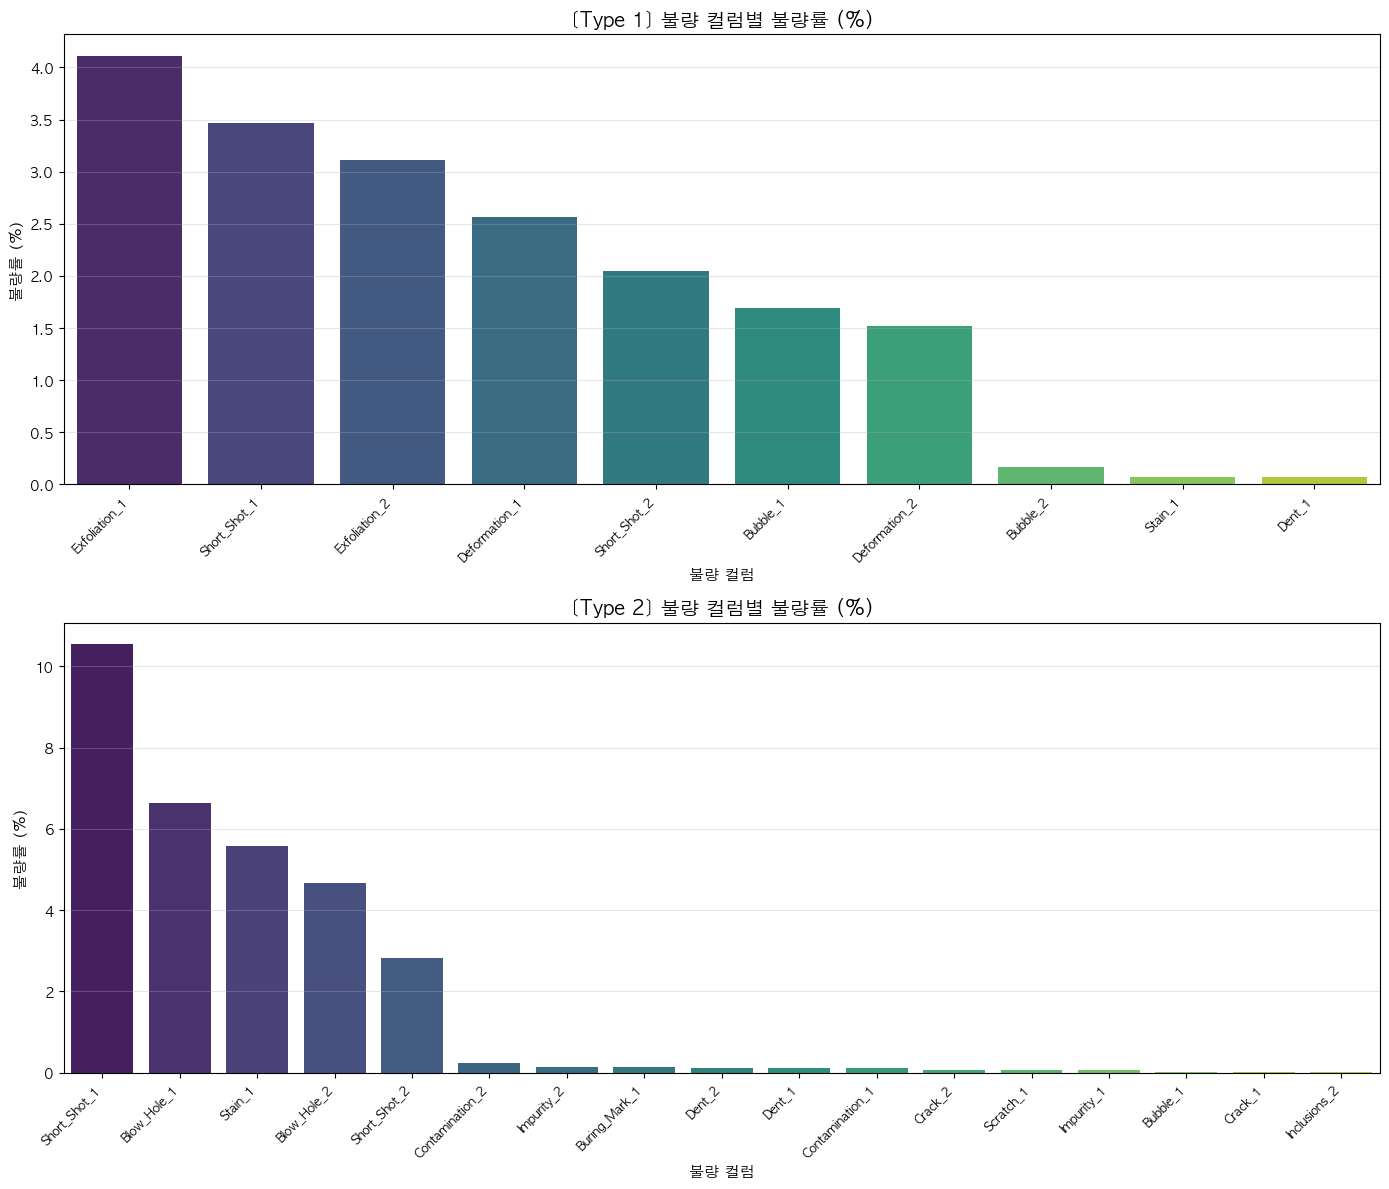

In [99]:
# Product_Type별 불량 컬럼 불량률 확인
type_dfs   = [product_type_1_df, product_type_2_df]
type_names = ['Type 1', 'Type 2']

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for ax, type_df, type_name in zip(axes, type_dfs, type_names):
    defect_cols = type_df['Defects'].columns
    defect_rates = {col: type_df[('Defects', col)].mean() * 100 for col in defect_cols if type_df[('Defects', col)].any()}
    defect_rates = pd.Series(defect_rates).sort_values(ascending=False)

    sns.barplot(x=defect_rates.index, y=defect_rates.values, palette='viridis', ax=ax)
    ax.set_title(f'[{type_name}] 불량 컬럼별 불량률 (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('불량 컬럼', fontsize=11)
    ax.set_ylabel('불량률 (%)', fontsize=11)
    ax.set_xticks(range(len(defect_rates)))
    ax.set_xticklabels(defect_rates.index, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

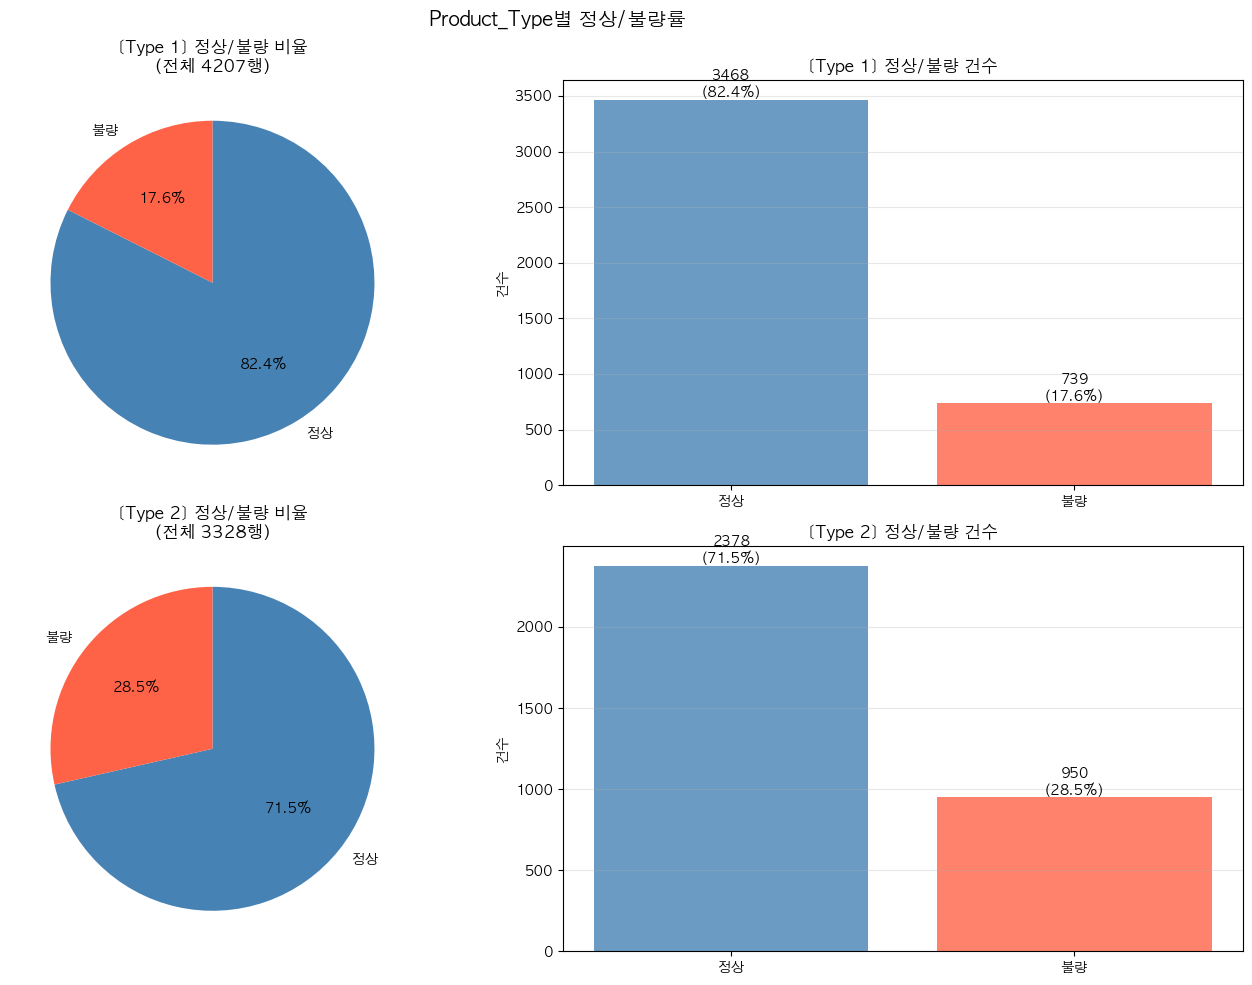

In [100]:
# 전체 정상/불량률 확인
# 레이아웃: 행=Type, 열=[파이차트 | 바차트]
type_dfs   = [product_type_1_df, product_type_2_df]
type_names = ['Type 1', 'Type 2']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (type_df, type_name) in enumerate(zip(type_dfs, type_names)):
    is_defect = type_df['Defects'].any(axis=1)
    defect_count = is_defect.sum()
    normal_count = (~is_defect).sum()
    total = len(type_df)

    # 파이차트 (col 0)
    axes[i, 0].pie(
        [normal_count, defect_count],
        labels=['정상', '불량'],
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        colors=['steelblue', 'tomato'],
    )
    axes[i, 0].set_title(f'[{type_name}] 정상/불량 비율\n(전체 {total}행)', fontsize=12, fontweight='bold')

    # 바차트 (col 1)
    axes[i, 1].bar(['정상', '불량'], [normal_count, defect_count], color=['steelblue', 'tomato'], alpha=0.8)
    axes[i, 1].set_title(f'[{type_name}] 정상/불량 건수', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel('건수')
    for j, v in enumerate([normal_count, defect_count]):
        axes[i, 1].text(j, v + total * 0.005, f'{v}\n({v/total*100:.1f}%)', ha='center', fontsize=10)
    axes[i, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Product_Type별 정상/불량률', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3-2. Process(공정), Sensor(센서) 데이터 이상치 분석

In [101]:
# Process(공정), Seonsor(센서) 데이터 이상치 탐색 컬럼 선택
target_cols = [
    ('Process', 'Velocity_1'), ('Process', 'Velocity_2'), ('Process', 'Velocity_3'),
    ('Process', 'High_Velocity'), ('Process', 'Cylinder_Pressure'), ('Process', 'Rapid_Rise_Time'),
    ('Process', 'Biscuit_Thickness'), ('Process', 'Clamping_Force'), ('Process', 'Cycle_Time'),
    ('Process', 'Pressure_Rise_Time'), ('Process', 'Casting_Pressure'), ('Process', 'Spray_Time'),
    ('Sensor', 'Melting_Furnace_Temp'), ('Sensor', 'Air_Pressure'),
    ('Sensor', 'Coolant_Temp'), ('Sensor', 'Coolant_Pressure'),
    ('Sensor', 'Factory_Temp'), ('Sensor', 'Factory_Humidity'),
]

# Process(공정), Seonsor(센서) 데이터 그래프 표시 정보
target_col_names = [
    '용탕 투입 속도 구간1', '용탕 투입 속도 구간2', '용탕 투입 속도 구간3',
    '고속 사출 속도', '사출 실린더 압력', '실린더 압력 급상승 시간',
    '주조 후 남은 비스킷 두께', '금형을 닫아주는 힘(형체력)', '1회 작업당 총 소요 시간',
    '최종 주조 압력까지 도달하는 시간', '용탕을 압착하는 최종 주조 압력', '금형 이형체 분무 전체 시간',
    '용해로 내부 용탕 온도', '작업용 에어 압력 측정값',
    '냉각수 온도 측정값', '냉각수 순환 압력',
    '공장 내부 온도 측정값', '공장 내부 습도 측정값',
]

# 기초통계
print("="*40)
print("Process/Sensor 데이터 기초통계 확인")
print("="*40)

df_full[target_cols].describe()

Process/Sensor 데이터 기초통계 확인


Process                                                            \
        Velocity_1   Velocity_2   Velocity_3 High_Velocity Cylinder_Pressure   
count  7535.000000  7535.000000  7535.000000   7535.000000       7535.000000   
mean      0.148219     0.168801     0.191193      2.319210        239.655607   
std       0.007134     0.004720     0.011563      0.222041         23.305451   
min       0.134000     0.158000     0.172000      0.000000        107.000000   
25%       0.142000     0.166000     0.181000      2.134000        217.000000   
50%       0.144000     0.168000     0.188000      2.161000        239.000000   
75%       0.156000     0.170000     0.202000      2.523000        265.000000   
max       0.180000     0.212000     0.234000      2.744000        266.000000   

                                                                     \
      Rapid_Rise_Time Biscuit_Thickness Clamping_Force   Cycle_Time   
count     7535.000000       7535.000000    7535.000000  7535.000000   
mean         0.009596         14.309622     306.433311    27.735979   
std          0.002148          3.286284      57.274965     8.716156   
min          0.000000          0.000000     238.000000    20.200000   
25%          0.008000         11.000000     255.000000    20.900000   
50%          0.009000         13.000000     258.000000    22.600000   
75%          0.012000         17.000000     372.000000    35.900000   
max          0.021000         24.000000     388.000000   218.600000   

                                                                     Sensor  \
      Pressure_Rise_Time Casting_Pressure   Spray_Time Melting_Furnace_Temp   
count        7535.000000      7535.000000  7535.000000          7535.000000   
mean            0.039348       856.944127     9.815979           680.652661   
std             0.003945       234.815490     1.842438            25.288666   
min             0.000000       516.000000     7.000000           635.300000   
25%             0.036000       596.000000     8.000000           656.700000   
50%             0.041000      1037.000000     9.700000           680.300000   
75%             0.043000      1053.000000    12.100000           703.100000   
max             0.046000      1164.000000    13.100000           730.000000   

                                                                                
      Air_Pressure Coolant_Temp Coolant_Pressure Factory_Temp Factory_Humidity  
count  7535.000000  7535.000000      7535.000000  7535.000000      7535.000000  
mean      6.109595    26.830126         2.701155    32.820969        61.688852  
std       0.647906     0.525149         0.052408     1.666748         6.990565  
min       4.600000    25.900000         2.580000    27.400000        45.500000  
25%       5.700000    26.500000         2.640000    31.900000        58.100000  
50%       6.200000    26.800000         2.720000    32.100000        63.000000  
75%       6.600000    27.200000         2.740000    33.700000        66.700000  
max       7.100000    28.100000         2.790000    37.000000        72.300000

In [102]:
# Product_Type별 왜도/첨도 확인
type_dfs   = [product_type_1_df, product_type_2_df]
type_names = ['Type 1', 'Type 2']

for type_df, type_name in zip(type_dfs, type_names):
    print("="*60)
    print(f"[{type_name}] 왜도/첨도 확인 (총 {len(type_df)}행)")
    print("="*60)

    for col, name in zip(target_cols, target_col_names):
        data = type_df[col]
        print(f"  {name} ({col[1]})")
        print(f"  범위: {data.min():.4f} ~ {data.max():.4f}")
        print(f"  왜도: {skew(data):.3f}  첨도: {kurtosis(data):.3f}")
        print()

[Type 1] 왜도/첨도 확인 (총 4207행)
  용탕 투입 속도 구간1 (Velocity_1)
  범위: 0.1340 ~ 0.1800
  왜도: 4.421  첨도: 26.421

  용탕 투입 속도 구간2 (Velocity_2)
  범위: 0.1620 ~ 0.2120
  왜도: 5.411  첨도: 34.506

  용탕 투입 속도 구간3 (Velocity_3)
  범위: 0.1720 ~ 0.2340
  왜도: 3.063  첨도: 15.616

  고속 사출 속도 (High_Velocity)
  범위: 0.0000 ~ 2.2850
  왜도: -19.152  첨도: 469.648

  사출 실린더 압력 (Cylinder_Pressure)
  범위: 107.0000 ~ 241.0000
  왜도: -0.587  첨도: 24.224

  실린더 압력 급상승 시간 (Rapid_Rise_Time)
  범위: 0.0000 ~ 0.0210
  왜도: 3.768  첨도: 31.186

  주조 후 남은 비스킷 두께 (Biscuit_Thickness)
  범위: 0.0000 ~ 22.0000
  왜도: -1.761  첨도: 16.873

  금형을 닫아주는 힘(형체력) (Clamping_Force)
  범위: 238.0000 ~ 263.0000
  왜도: -0.895  첨도: 4.157

  1회 작업당 총 소요 시간 (Cycle_Time)
  범위: 20.2000 ~ 218.6000
  왜도: 24.489  첨도: 643.732

  최종 주조 압력까지 도달하는 시간 (Pressure_Rise_Time)
  범위: 0.0000 ~ 0.0460
  왜도: -2.955  첨도: 24.525

  용탕을 압착하는 최종 주조 압력 (Casting_Pressure)
  범위: 516.0000 ~ 1164.0000
  왜도: -0.593  첨도: 24.492

  금형 이형체 분무 전체 시간 (Spray_Time)
  범위: 7.0000 ~ 10.8000
  왜도: 1.673  첨도

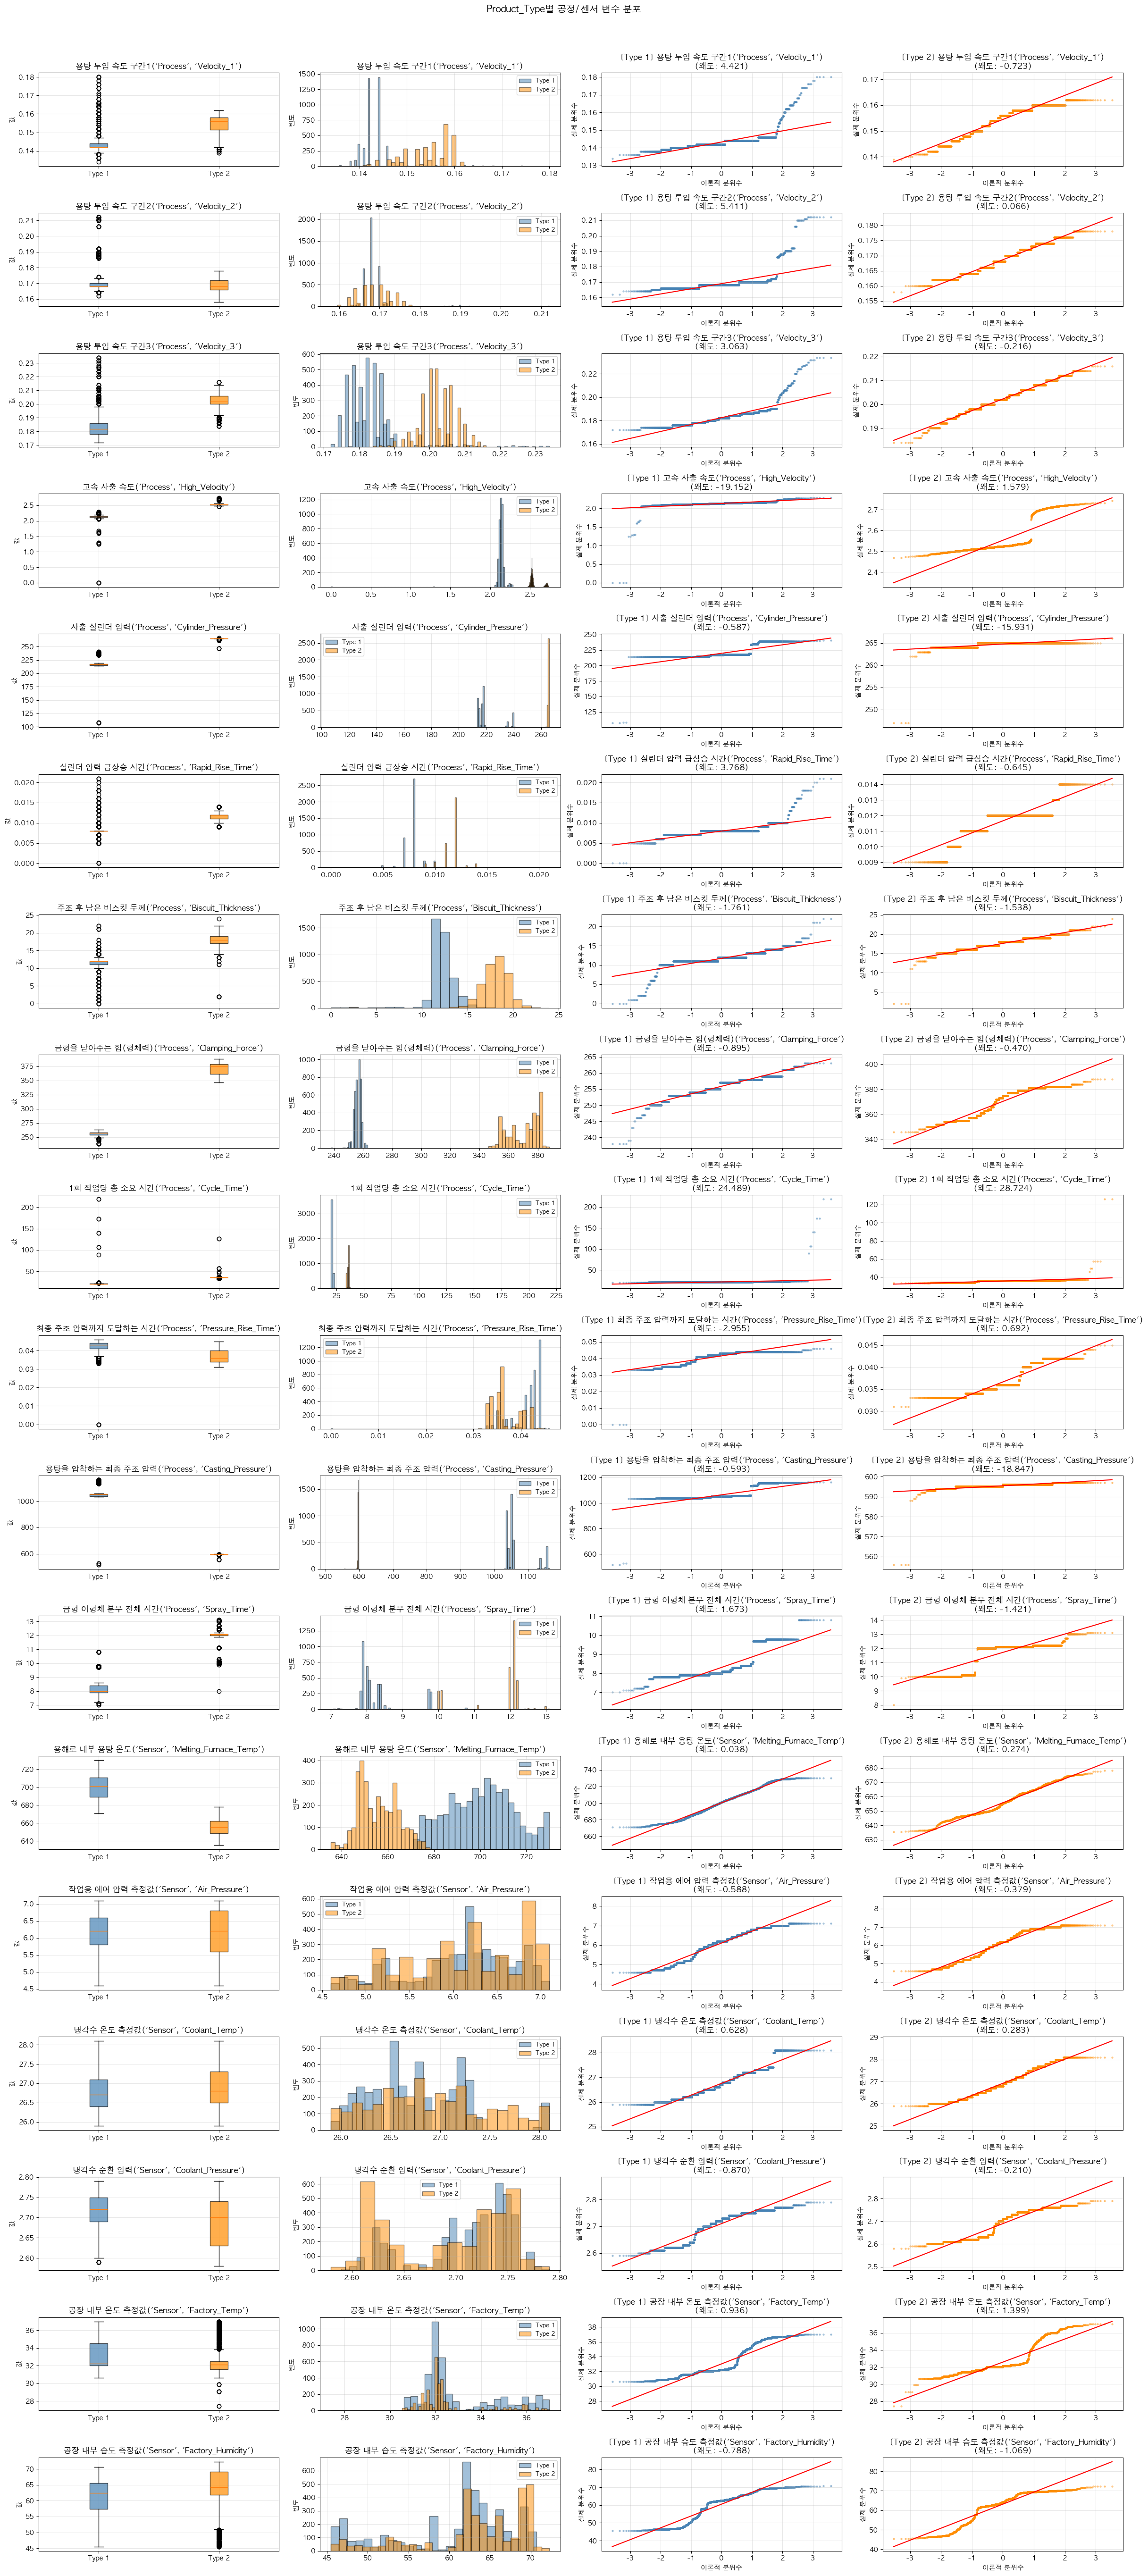

In [103]:
# Product_Type별 박스플롯 & 히스토그램 & Q-Q Plot
# 컬럼 구성: [박스플롯 | 히스토그램 | Q-Q Type1 | Q-Q Type2]
fig, axes = plt.subplots(len(target_cols), 4, figsize=(24, len(target_cols) * 3))

type_dfs   = [product_type_1_df, product_type_2_df]
type_names = ['Type 1', 'Type 2']
colors     = ['steelblue', 'darkorange']

for i, (col, name) in enumerate(zip(target_cols, target_col_names)):
    data_type1 = product_type_1_df[col]
    data_type2 = product_type_2_df[col]

    # 박스플롯 (col 0)
    bp = axes[i, 0].boxplot(
        [data_type1, data_type2],
        labels=['Type 1', 'Type 2'],
        patch_artist=True
    )
    for patch, color in zip(bp['boxes'], ['steelblue', 'darkorange']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i, 0].set_title(f'{name}{col}')
    axes[i, 0].set_ylabel('값')
    axes[i, 0].grid(True, alpha=0.3)

    # 히스토그램 (col 1)
    axes[i, 1].hist(data_type1, bins='auto', alpha=0.5, color='steelblue', edgecolor='black', label='Type 1')
    axes[i, 1].hist(data_type2, bins='auto', alpha=0.5, color='darkorange', edgecolor='black', label='Type 2')
    axes[i, 1].set_title(f'{name}{col}')
    axes[i, 1].set_ylabel('빈도')
    axes[i, 1].legend(fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)

    # Q-Q Plot (col 2: Type1, col 3: Type2)
    for qq_col, (type_df, type_name, color) in enumerate(zip(type_dfs, type_names, colors)):
        data = type_df[col].dropna()
        res = stats.probplot(data, dist='norm')

        theoretical = res[1]
        axes[i, 2 + qq_col].plot(
            [res[0][0].min(), res[0][0].max()],
            [theoretical[1] + theoretical[0] * res[0][0].min(),
             theoretical[1] + theoretical[0] * res[0][0].max()],
            color='red', linewidth=1.5
        )
        axes[i, 2 + qq_col].scatter(res[0][0], res[0][1], color=color, alpha=0.4, s=5)
        axes[i, 2 + qq_col].set_title(f'[{type_name}] {name}{col}\n(왜도: {skew(data):.3f})')
        axes[i, 2 + qq_col].set_xlabel('이론적 분위수')
        axes[i, 2 + qq_col].set_ylabel('실제 분위수')
        axes[i, 2 + qq_col].grid(True, alpha=0.3)

plt.suptitle('Product_Type별 공정/센서 변수 분포', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [104]:
# Product_Type별 IQR 기반 이상치 탐색
type_dfs   = [product_type_1_df, product_type_2_df]
type_names = ['Type 1', 'Type 2']

for type_df, type_name in zip(type_dfs, type_names):
    total_outlier_count = 0
    print(f"{'='*60}")
    print(f"[{type_name}] IQR 기반 이상치 탐색 (총 {len(type_df)}행)")
    print(f"{'='*60}")

    for col, name in zip(target_cols, target_col_names):
        data = type_df[col]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = ((data < lower_bound) | (data > upper_bound)).sum()
        total_outlier_count += outlier_count

        print(f"  {col}")
        print(f"  정상 범위: {lower_bound:.4f} ~ {upper_bound:.4f}")
        print(f"  이상치 개수: {outlier_count}개 ({outlier_count / len(type_df) * 100:.2f}%)\n")

    print(f"  총 이상치 합계: {total_outlier_count}개\n")

[Type 1] IQR 기반 이상치 탐색 (총 4207행)
  ('Process', 'Velocity_1')
  정상 범위: 0.1390 ~ 0.1470
  이상치 개수: 250개 (5.94%)

  ('Process', 'Velocity_2')
  정상 범위: 0.1650 ~ 0.1730
  이상치 개수: 192개 (4.56%)

  ('Process', 'Velocity_3')
  정상 범위: 0.1660 ~ 0.1980
  이상치 개수: 128개 (3.04%)

  ('Process', 'High_Velocity')
  정상 범위: 2.0720 ~ 2.2000
  이상치 개수: 175개 (4.16%)

  ('Process', 'Cylinder_Pressure')
  정상 범위: 210.5000 ~ 222.5000
  이상치 개수: 714개 (16.97%)

  ('Process', 'Rapid_Rise_Time')
  정상 범위: 0.0080 ~ 0.0080
  이상치 개수: 1503개 (35.73%)

  ('Process', 'Biscuit_Thickness')
  정상 범위: 9.5000 ~ 13.5000
  이상치 개수: 400개 (9.51%)

  ('Process', 'Clamping_Force')
  정상 범위: 248.0000 ~ 264.0000
  이상치 개수: 25개 (0.59%)

  ('Process', 'Cycle_Time')
  정상 범위: 19.9500 ~ 21.9500
  이상치 개수: 642개 (15.26%)

  ('Process', 'Pressure_Rise_Time')
  정상 범위: 0.0365 ~ 0.0485
  이상치 개수: 512개 (12.17%)

  ('Process', 'Casting_Pressure')
  정상 범위: 1015.0000 ~ 1079.0000
  이상치 개수: 714개 (16.97%)

  ('Process', 'Spray_Time')
  정상 범위: 7.1500 ~ 9.1500
  이상치

In [105]:
type_dfs   = [product_type_1_df, product_type_2_df]
type_names = ['Type 1', 'Type 2']

print("="*60)
print("IQR 상한 값 보다 높은 값:")
print("="*60)
for type_df, type_name in zip(type_dfs, type_names):
    cycle_time_high = type_df[('Process', 'Cycle_Time')] > 100
    values = type_df.loc[cycle_time_high, ('Process', 'Cycle_Time')]
    print(f"[{type_name}] Cycle_Time > 100 인 값:")
    print(values.values)
    print()

print("="*60)
print("IQR 하한 값 보다 낮은 값:")
print("="*60)
for type_df, type_name in zip(type_dfs, type_names):
    cycle_time_high = type_df[('Process', 'Cycle_Time')] < 33
    values = type_df.loc[cycle_time_high, ('Process', 'Cycle_Time')]
    print(f"[{type_name}] Cycle_Time < 33 인 값:")
    print(values.values)
    print()

IQR 상한 값 보다 높은 값:
[Type 1] Cycle_Time > 100 인 값:
[173.  173.  106.3 106.3 139.8 139.8 218.6 218.6]

[Type 2] Cycle_Time > 100 인 값:
[125.9 125.9]

IQR 하한 값 보다 낮은 값:
[Type 1] Cycle_Time < 33 인 값:
[20.7 20.7 20.8 ... 20.7 20.8 20.8]

[Type 2] Cycle_Time < 33 인 값:
[]



In [106]:
# Product_Type별 Cycle_Time > 100인 행 불량 비율 비교
type_dfs   = [product_type_1_df, product_type_2_df]
type_names = ['Type 1', 'Type 2']

for type_df, type_name in zip(type_dfs, type_names):
    cycle_time_high = type_df[('Process', 'Cycle_Time')] > 100
    df_filtered = type_df[cycle_time_high]

    print(f"{'='*65}")
    print(f"[{type_name}] 전체: {len(type_df)}행 / Cycle_Time > 100: {len(df_filtered)}행 ({len(df_filtered)/len(type_df)*100:.2f}%)")
    print(f"{'='*65}")
    print(f"  {'컬럼':<20} {'전체 불량 비율':>15} {'Cycle_Time>100 불량 비율':>25}")
    print(f"  {'-'*60}")

    for col in df_full['Defects'].columns:
        total_ratio   = (type_df[('Defects', col)] == 1).sum() / len(type_df) * 100
        filtered_ratio = (df_filtered[('Defects', col)] == 1).sum() / len(df_filtered) * 100 if len(df_filtered) > 0 else 0
        if filtered_ratio > 0 or total_ratio > 0:
            print(f"  {col:<20} {total_ratio:>13.2f}%  {filtered_ratio:>23.2f}%")
    print()

[Type 1] 전체: 4207행 / Cycle_Time > 100: 8행 (0.19%)
  컬럼                          전체 불량 비율      Cycle_Time>100 불량 비율
  ------------------------------------------------------------
  Short_Shot_1                  3.47%                     0.00%
  Bubble_1                      1.69%                     0.00%
  Exfoliation_1                 4.11%                     0.00%
  Stain_1                       0.07%                     0.00%
  Dent_1                        0.07%                     0.00%
  Deformation_1                 2.57%                     0.00%
  Short_Shot_2                  2.04%                     0.00%
  Bubble_2                      0.17%                     0.00%
  Exfoliation_2                 3.11%                    25.00%
  Deformation_2                 1.52%                     0.00%

[Type 2] 전체: 3328행 / Cycle_Time > 100: 2행 (0.06%)
  컬럼                          전체 불량 비율      Cycle_Time>100 불량 비율
  ------------------------------------------------------------
  S